# ABM Experiments and Stress Testing
This notebook runs four experiments:
- Uncontrolled baselines
- Policy effectiveness
- Mean-field limit breakdown
- Emergence and phase transitions

In [1]:
from pathlib import Path
import json
import argparse
import sys
import importlib
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC = ROOT / 'src'
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import scripts.run_abm_experiments as rae
importlib.reload(rae)
run_all_experiments = rae.run_all_experiments

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)

Device: cuda


In [2]:
if device == 'cuda':
    torch.cuda.empty_cache()

mc_paths = 500

args = argparse.Namespace(
    checkpoint='results/checkpoints/systemic_risk_global_dp_bins_case_1_seed7.pt',
    output_dir='results/abm',
    case='case_1',
    device=device,
    state_dim=1,
    steps=50,
    horizon=0.5,
    sigma=0.5,
    default_threshold=-0.5,
    target_cascade_rate=0.35,
    q_min=0.1,
    q_max=1.5,
    q_steps=15,
    agents=100,
    core_hubs=10,
    er_p=0.08,
    mc_paths=mc_paths,
    seed=42,
    n_grid='10,30,100,300,1000',
    q_grid='0.4,0.6,0.8,1.0,1.2',
    phase_q_min=0.0,
    phase_q_max=2.0,
    phase_q_steps=21,
    phase_sigma=0.1,
    phase_threshold=0.0,
    phase_initial_mean=0.5,
    phase_horizon=1.0,
    phase_steps=100,
    phase_stress_fraction=0.1,
    phase_stress_value=-5.0,
)

try:
    out = run_all_experiments(args)
except torch.OutOfMemoryError:
    if device == 'cuda':
        torch.cuda.empty_cache()
    args.device = 'cpu'
    args.mc_paths = 200
    out = run_all_experiments(args)

Path(ROOT / args.output_dir).mkdir(parents=True, exist_ok=True)
out_path = ROOT / args.output_dir / 'abm_experiments_notebook.json'
out_path.write_text(json.dumps(out, indent=2), encoding='utf-8')
print('Saved:', out_path)
print('Calibrated q:', out['calibration']['selected_q'])
print('device used:', args.device)
print('mc_paths:', args.mc_paths)

Saved: C:\Users\adoni\Desktop\Interactions\project\results\abm\abm_experiments_notebook.json
Calibrated q: 0.10000000149011612
device used: cuda
mc_paths: 500


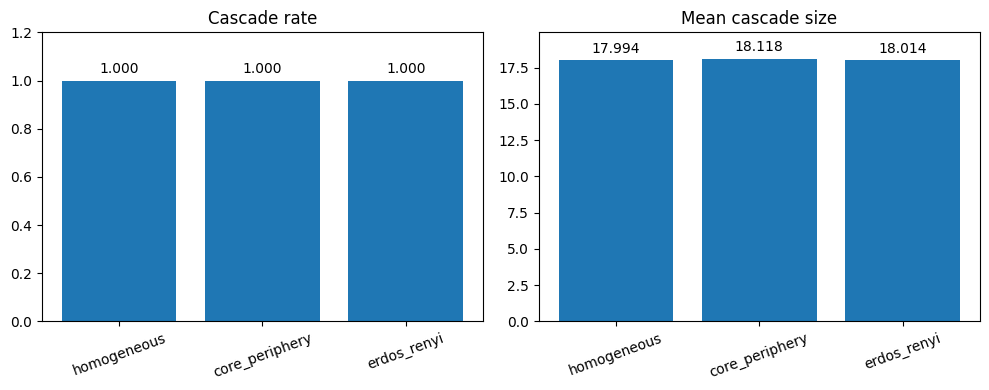

In [15]:
exp1 = out['experiment_1_uncontrolled']
names = ['homogeneous', 'core_periphery', 'erdos_renyi']
rates = [exp1[n]['stats']['cascade_rate'] for n in names]
sizes = [exp1[n]['stats']['mean_cascade_size'] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
bar_container = axes[0].bar(names, rates)
axes[0].bar_label(bar_container, fmt='%.3f', padding=3)
axes[0].set_title('Cascade rate')
axes[0].set_ylim(0, 1.2)
axes[0].tick_params(axis='x', rotation=20)

bar_container = axes[1].bar(names, sizes)
axes[1].bar_label(bar_container, fmt='%.3f', padding=3)
axes[1].set_title('Mean cascade size')
axes[1].set_ylim(0, max(sizes)*1.1)
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

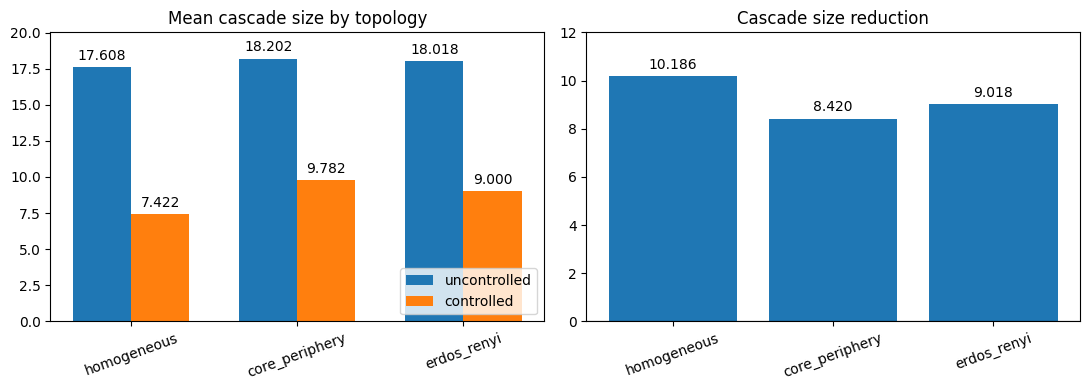

uncontrolled rates: [1.0, 1.0, 1.0]
controlled rates: [1.0, 1.0, 1.0]
rate reduction: [0.0, 0.0, 0.0]
size reduction: [10.186001300811768, 8.420001029968262, 9.018001556396484]
Mismatch vs homogeneous: {'core_periphery': {'rate': 0.0, 'size': 1.7660002708435059}, 'erdos_renyi': {'rate': 0.0, 'size': 1.1679997444152832}}


In [ ]:
exp2 = out['experiment_2_controlled']
uncontrolled_rates = [exp2[n]['uncontrolled']['stats']['cascade_rate'] for n in names]
controlled_rates = [exp2[n]['controlled']['stats']['cascade_rate'] for n in names]
uncontrolled_sizes = [exp2[n]['uncontrolled']['stats']['mean_cascade_size'] for n in names]
controlled_sizes = [exp2[n]['controlled']['stats']['mean_cascade_size'] for n in names]
reductions = [exp2[n]['cascade_reduction'] for n in names]
size_reductions = [exp2[n]['cascade_size_reduction'] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
width = 0.35
x = list(range(len(names)))

bar_container1 = axes[0].bar([i - width / 2 for i in x], uncontrolled_sizes, width=width, label='uncontrolled')
bar_container2 = axes[0].bar([i + width / 2 for i in x], controlled_sizes, width=width, label='controlled')
axes[0].bar_label(bar_container1, fmt='%.3f', padding=3)
axes[0].bar_label(bar_container2, fmt='%.3f', padding=3)
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=20)
axes[0].set_ylim(0, max(uncontrolled_sizes + controlled_sizes)*1.1)
axes[0].set_title('Mean cascade size by topology')
axes[0].legend(loc='lower right')

bar_container = axes[1].bar(names, size_reductions)
axes[1].bar_label(bar_container, fmt='%.3f', padding=3)
axes[1].axhline(0.0, color='black', linewidth=0.8)
axes[1].set_title('Cascade size reduction')
axes[1].set_ylim(0, 12)
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

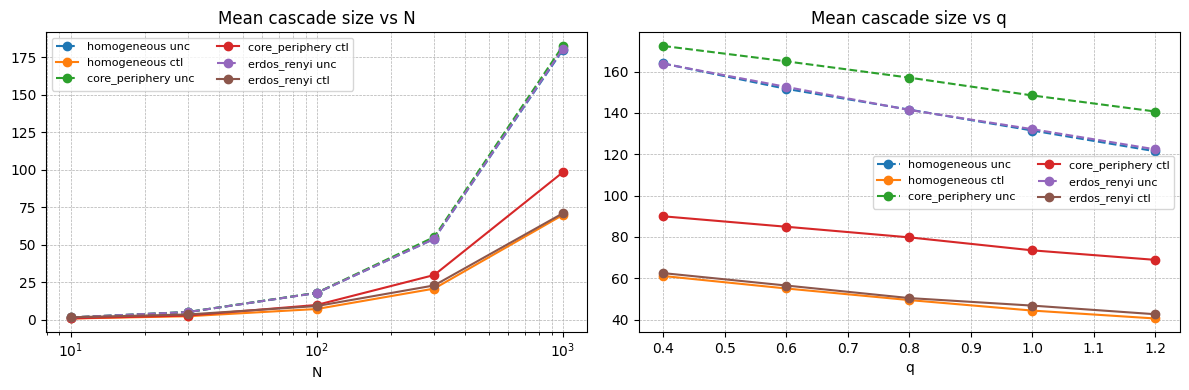

N-grid controlled sizes (homogeneous): [0.9760000705718994, 2.4800000190734863, 7.306000232696533, 20.880001068115234, 69.92000579833984]
q-grid controlled sizes (homogeneous): [61.13600158691406, 55.10400390625, 49.496002197265625, 44.42000198364258, 40.592002868652344]


In [ ]:
exp3 = out['experiment_3_limit_breakdown']
vs_n = exp3['vs_N']
n_values = [item['N'] for item in vs_n]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name in names:
    c_series = [item['topologies'][name]['controlled_mean_cascade_size'] for item in vs_n]
    u_series = [item['topologies'][name]['uncontrolled_mean_cascade_size'] for item in vs_n]
    axes[0].plot(n_values, u_series, marker='o', linestyle='--', label=f'{name} unc')
    axes[0].plot(n_values, c_series, marker='o', label=f'{name} ctl')
axes[0].set_xscale('log')
axes[0].set_title('Mean cascade size vs N')
axes[0].set_xlabel('N')
axes[0].legend(ncol=2, fontsize=8)
axes[0].grid(True, which='both', linestyle='--', linewidth=0.5)

vs_q = exp3['vs_q']
q_values = [item['q'] for item in vs_q]
for name in names:
    c_series = [item['topologies'][name]['controlled_mean_cascade_size'] for item in vs_q]
    u_series = [item['topologies'][name]['uncontrolled_mean_cascade_size'] for item in vs_q]
    axes[1].plot(q_values, u_series, marker='o', linestyle='--', label=f'{name} unc')
    axes[1].plot(q_values, c_series, marker='o', label=f'{name} ctl')
axes[1].set_title('Mean cascade size vs q')
axes[1].set_xlabel('q')
axes[1].legend(ncol=2, fontsize=8)
axes[1].grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

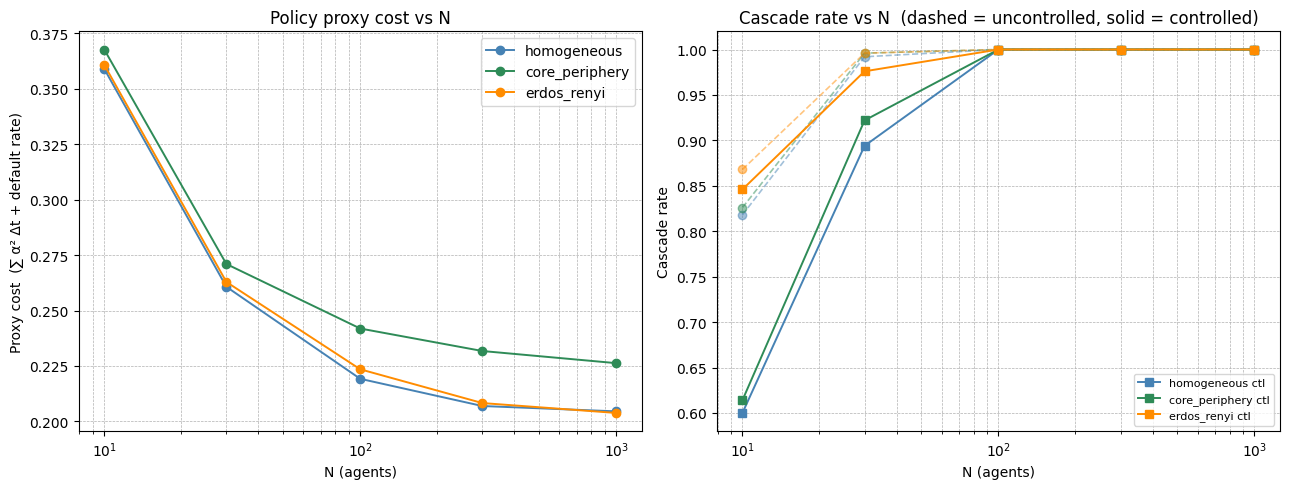

Proxy cost vs N (homogeneous):
  N=   10: proxy_cost=0.3589
  N=   30: proxy_cost=0.2607
  N=  100: proxy_cost=0.2192
  N=  300: proxy_cost=0.2070
  N= 1000: proxy_cost=0.2046


In [20]:
topo_colors = {'homogeneous': 'steelblue', 'core_periphery': 'seagreen', 'erdos_renyi': 'darkorange'}

n_values_plot = [item['N'] for item in vs_n]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name in names:
    proxy_costs = [item['topologies'][name]['controlled_proxy_cost']    for item in vs_n]
    ctrl_rates  = [item['topologies'][name]['controlled_cascade_rate']  for item in vs_n]
    unc_rates   = [item['topologies'][name]['uncontrolled_cascade_rate'] for item in vs_n]
    c = topo_colors[name]
    axes[0].plot(n_values_plot, proxy_costs, marker='o', lw=1.4, label=name, color=c)
    axes[1].plot(n_values_plot, unc_rates,  marker='o', lw=1.2, ls='--', color=c, alpha=0.5)
    axes[1].plot(n_values_plot, ctrl_rates, marker='s', lw=1.4, label=f'{name} ctl', color=c)

axes[0].set_xscale('log')
axes[0].set_xlabel('N (agents)')
axes[0].set_ylabel('Proxy cost  (∑ α² Δt + default rate)')
axes[0].set_title('Policy proxy cost vs N')
axes[0].legend()
axes[0].grid(True, which='both', ls='--', lw=0.5)

axes[1].set_xscale('log')
axes[1].set_xlabel('N (agents)')
axes[1].set_ylabel('Cascade rate')
axes[1].set_title('Cascade rate vs N  (dashed = uncontrolled, solid = controlled)')
axes[1].legend(fontsize=8)
axes[1].grid(True, which='both', ls='--', lw=0.5)

plt.tight_layout()
plt.show()

print('Proxy cost vs N (homogeneous):')
for item in vs_n:
    c = item['topologies']['homogeneous']['controlled_proxy_cost']
    print(f"  N={item['N']:>5}: proxy_cost={c:.4f}")


## Emergence and phase transition

We sweep $q$ from subcritical to supercritical on the **uncontrolled** homogeneous ABM (no hub shock) and measure how the cascade rate and mean cascade size respond.

Near the critical $q^*$, the system exhibits a collective phase transition: a macroscopic fraction of agents defaults even though each individual coupling is weak.

The three sub-experiments are:

1. Cascade rate and mean size vs $q$: identify $q^*$ as the inflection point.
2. Heavy-tail check near $q^*$: a log-log plot of the cascade-size distribution; a power-law tail signals proximity to criticality.
3. Policy-induced critical-point shift: the MFC policy effectively shifts the phase boundary to a higher $q^*$, quantifying the policy's suppression power as a function of coupling strength.

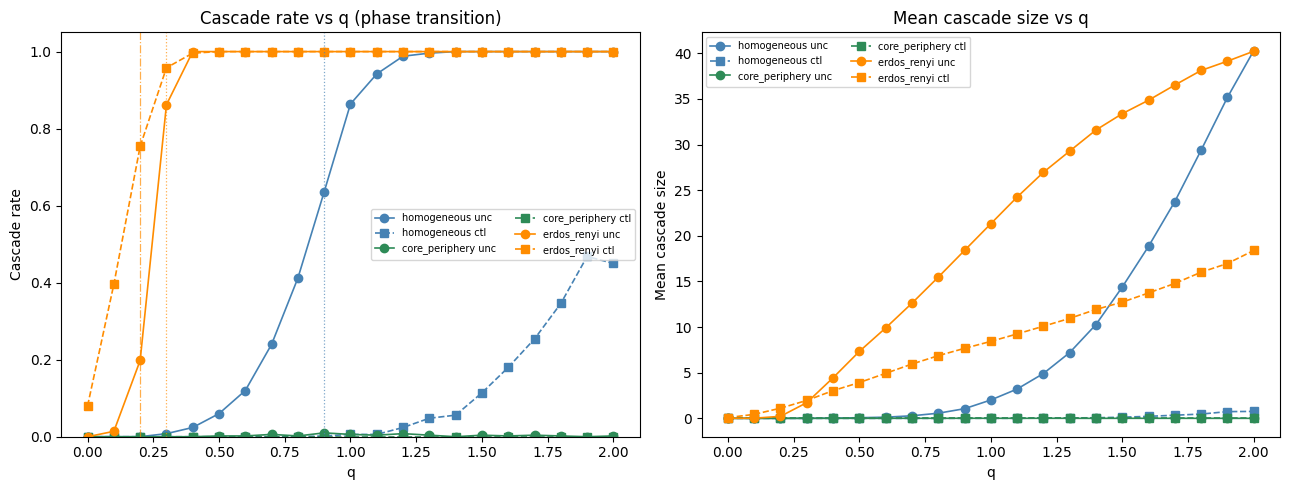

homogeneous: critical_q_uncontrolled=0.9000000357627869, critical_q_controlled=None
core_periphery: critical_q_uncontrolled=None, critical_q_controlled=None
erdos_renyi: critical_q_uncontrolled=0.30000001192092896, critical_q_controlled=0.20000000298023224


In [21]:
exp4 = out['experiment_4_phase_transition']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = {'homogeneous': 'steelblue', 'core_periphery': 'seagreen', 'erdos_renyi': 'darkorange'}

for topo_name, topo_data in exp4.items():
    unc4_topo = topo_data['uncontrolled']
    ctl4_topo = topo_data['controlled']
    q4 = [row['q'] for row in unc4_topo]
    c = colors.get(topo_name, 'grey')
    axes[0].plot(q4, [row['cascade_rate'] for row in unc4_topo], marker='o', color=c,
                 lw=1.2, label=f'{topo_name} unc')
    axes[0].plot(q4, [row['cascade_rate'] for row in ctl4_topo], marker='s', color=c,
                 lw=1.2, ls='--', label=f'{topo_name} ctl')
    axes[1].plot(q4, [row['mean_cascade_size'] for row in unc4_topo], marker='o', color=c,
                 lw=1.2, label=f'{topo_name} unc')
    axes[1].plot(q4, [row['mean_cascade_size'] for row in ctl4_topo], marker='s', color=c,
                 lw=1.2, ls='--', label=f'{topo_name} ctl')

for topo_name, topo_data in exp4.items():
    cq_unc = topo_data.get('critical_q_uncontrolled')
    cq_ctl = topo_data.get('critical_q_controlled')
    c = colors.get(topo_name, 'grey')
    if cq_unc is not None:
        axes[0].axvline(cq_unc, color=c, ls=':', lw=0.9, alpha=0.7)
    if cq_ctl is not None:
        axes[0].axvline(cq_ctl, color=c, ls='-.', lw=0.9, alpha=0.7)

axes[0].set_xlabel('q')
axes[0].set_ylabel('Cascade rate')
axes[0].set_title('Cascade rate vs q (phase transition)')
axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=7, ncol=2)
axes[1].set_xlabel('q')
axes[1].set_ylabel('Mean cascade size')
axes[1].set_title('Mean cascade size vs q')
axes[1].legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

for topo_name, topo_data in exp4.items():
    print(f"{topo_name}: critical_q_uncontrolled={topo_data.get('critical_q_uncontrolled')}, "
          f"critical_q_controlled={topo_data.get('critical_q_controlled')}")

unc4 = exp4['homogeneous']['uncontrolled']
ctl4 = exp4['homogeneous']['controlled']
q4 = [row['q'] for row in unc4]
cq_unc = exp4['homogeneous'].get('critical_q_uncontrolled')
cq_ctl = exp4['homogeneous'].get('critical_q_controlled')


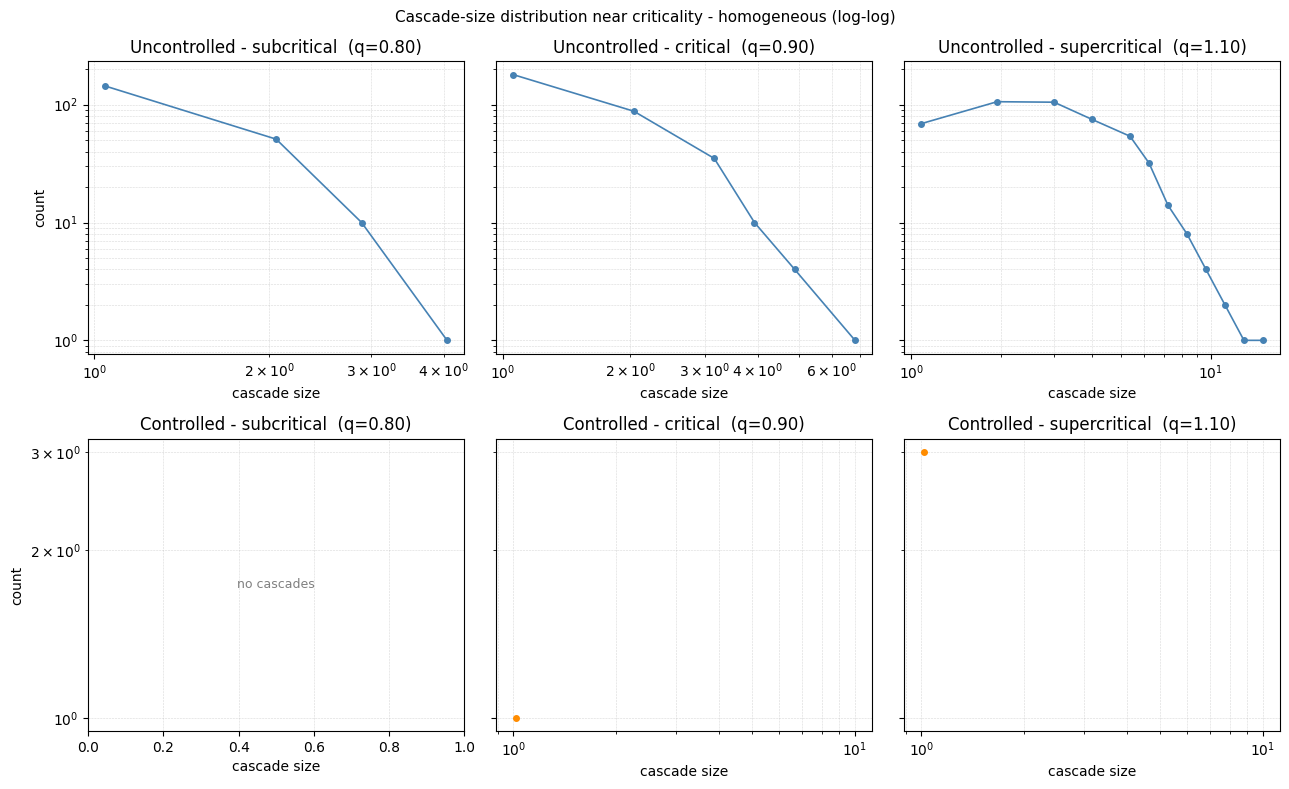

In [22]:
import numpy as np

q4_arr = q4
crit_q = cq_unc

below_idx = max((i for i, q in enumerate(q4_arr) if q < (crit_q or 0)), default=0)
at_idx    = min(range(len(q4_arr)), key=lambda i: abs(q4_arr[i] - (crit_q or q4_arr[len(q4_arr)//2])))
above_idx = min(at_idx + 2, len(q4_arr) - 1)

fig, axes = plt.subplots(2, 3, figsize=(13, 8), sharey='row')

for col, (idx, qlabel) in enumerate(zip(
    [below_idx, at_idx, above_idx],
    ['subcritical', 'critical', 'supercritical'],
)):
    for row, (data, row_label, color) in enumerate([
        (unc4, 'Uncontrolled', 'steelblue'),
        (ctl4, 'Controlled',   'darkorange'),
    ]):
        ax = axes[row][col]
        sizes = [s for s in data[idx]['cascade_size_distribution'] if s > 0]
        if sizes:
            log_min = np.log10(max(min(sizes), 1e-1))
            log_max = np.log10(max(sizes) + 1)
            if log_max > log_min:
                bins = np.logspace(log_min, log_max, 20)
                counts, edges = np.histogram(sizes, bins=bins)
                centers = 0.5 * (edges[:-1] + edges[1:])
                mask = counts > 0
                ax.loglog(centers[mask], counts[mask], marker='o', markersize=4, lw=1.2, color=color)
            else:
                ax.text(0.5, 0.5, 'all same size', ha='center', va='center',
                        transform=ax.transAxes, fontsize=9)
        else:
            ax.text(0.5, 0.5, 'no cascades', ha='center', va='center',
                    transform=ax.transAxes, fontsize=9, color='grey')
        ax.set_title(f'{row_label} - {qlabel}  (q={q4_arr[idx]:.2f})')
        ax.set_xlabel('cascade size')
        if col == 0:
            ax.set_ylabel('count')
        ax.grid(True, which='both', ls='--', lw=0.4, alpha=0.5)

fig.suptitle('Cascade-size distribution near criticality - homogeneous (log-log)', fontsize=11)
plt.tight_layout()
plt.show()


### Re-run with calibrated phase parameters

Using `phase_initial_mean=0.5` and `phase_sigma=0.1` gives healthy agents a large safety margin and tiny noise, making the policy trivially effective. Below we re-run with parameters matched to the rest of the ABM experiments (`phase_initial_mean=0.05`, `phase_sigma=0.5`) so that the policy is challenged by conditions close to those it was trained on.

In [ ]:
from pathlib import Path
from mfnn_control import ABMConfig

CALIB_SIGMA = 0.5
CALIB_INITIAL_MEAN = 0.05

checkpoint_path = (ROOT / args.checkpoint).resolve()
policy_robust   = rae.load_policy_from_checkpoint(checkpoint_path, args.device)

calib_config = ABMConfig(
    horizon=args.phase_horizon,
    steps=args.phase_steps,
    sigma=CALIB_SIGMA,
    interaction_q=float(out['calibration']['selected_q']),
    state_dim=args.state_dim,
    default_threshold=args.phase_threshold,
)

topo_phase = rae.build_topologies(args.agents, args.core_hubs, args.er_p, args.device)
phase_q_sweep = torch.linspace(args.phase_q_min, args.phase_q_max, args.phase_q_steps).tolist()

exp4_calib = rae.experiment_4_phase_transition(
    calib_config,
    args.agents,
    phase_q_sweep,
    args.case,
    args.mc_paths,
    args.state_dim,
    args.device,
    policy_robust,
    topo_phase,
    phase_sigma=CALIB_SIGMA,
    phase_threshold=args.phase_threshold,
    phase_initial_mean=CALIB_INITIAL_MEAN,
    phase_horizon=args.phase_horizon,
    phase_steps=args.phase_steps,
    phase_stress_fraction=args.phase_stress_fraction,
    phase_stress_value=args.phase_stress_value,
)

for topo_name, topo_data in exp4_calib.items():
    print(f"{topo_name}: critical_q_uncontrolled={topo_data.get('critical_q_uncontrolled')}, "
          f"critical_q_controlled={topo_data.get('critical_q_controlled')}")

homogeneous: critical_q_uncontrolled=0.0, critical_q_controlled=0.0
core_periphery: critical_q_uncontrolled=0.0, critical_q_controlled=0.0
erdos_renyi: critical_q_uncontrolled=0.0, critical_q_controlled=0.0


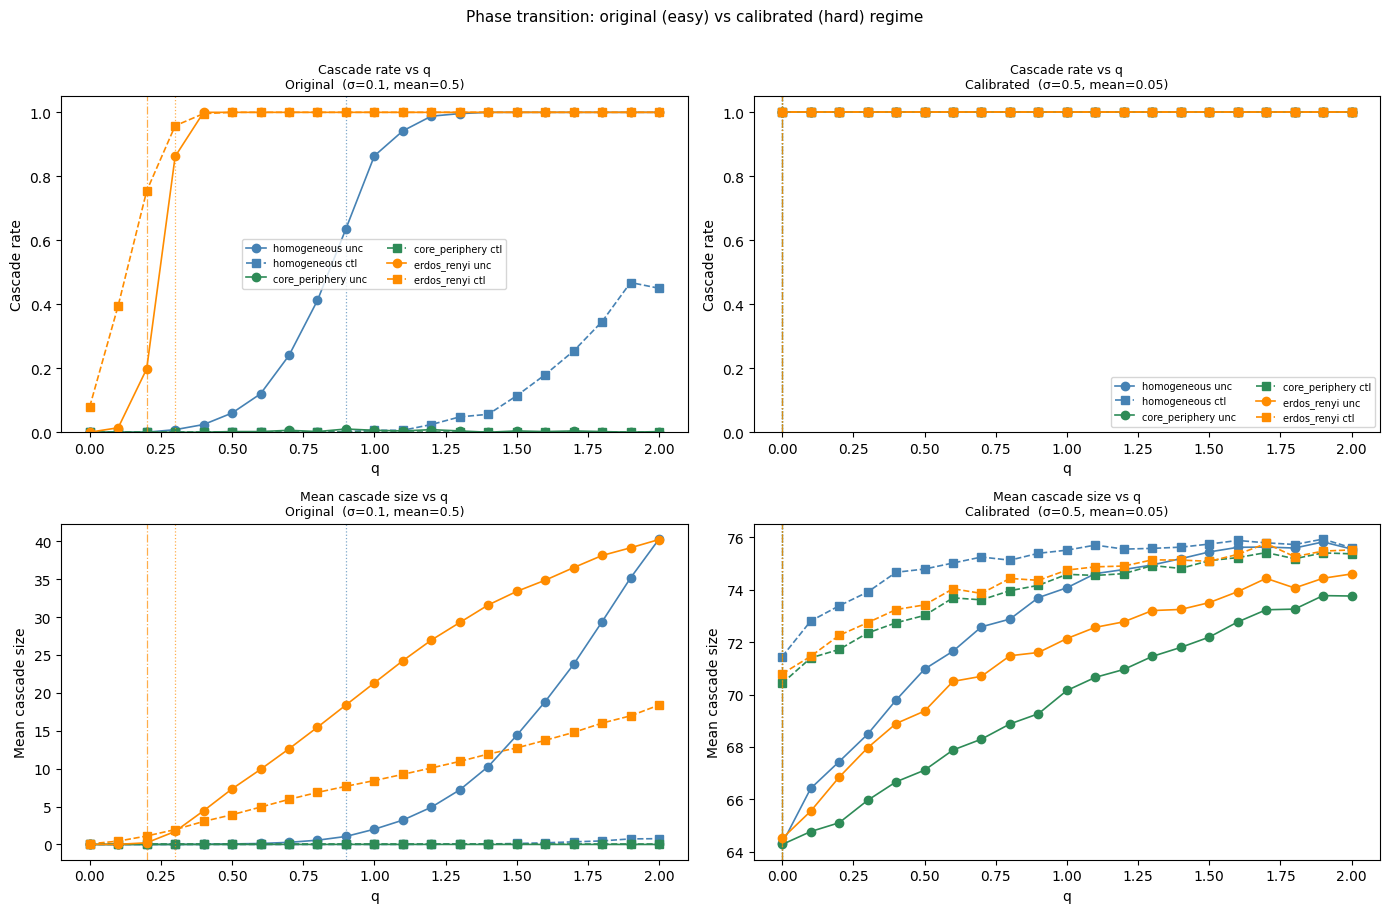

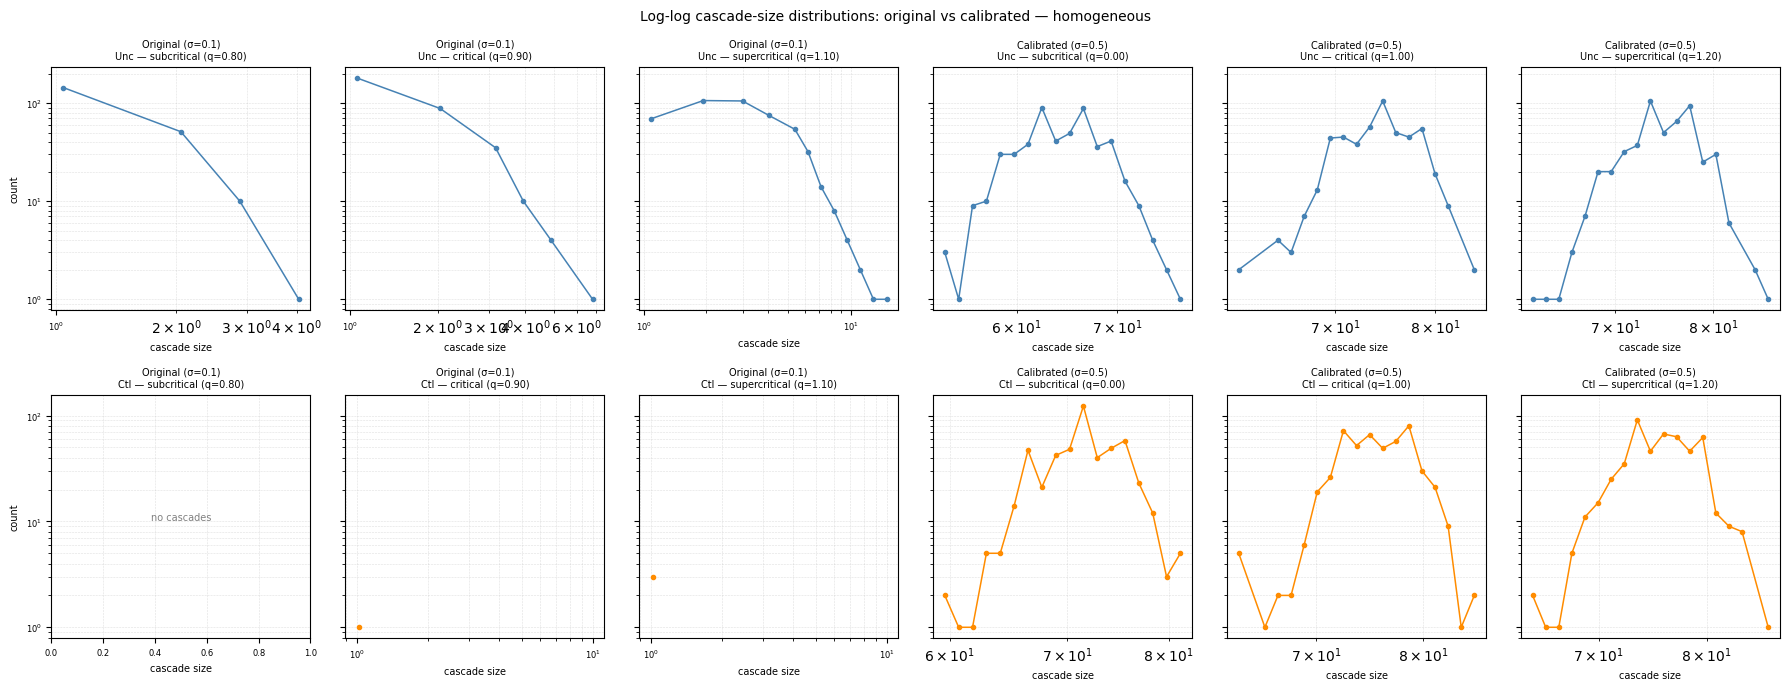

In [25]:
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plot_colors = {'homogeneous': 'steelblue', 'core_periphery': 'seagreen', 'erdos_renyi': 'darkorange'}

for col, (exp4_use, label) in enumerate([
    (exp4,        f'Original  (σ={args.phase_sigma}, mean={args.phase_initial_mean})'),
    (exp4_calib,  f'Calibrated  (σ={CALIB_SIGMA}, mean={CALIB_INITIAL_MEAN})'),
]):
    for topo_name, topo_data in exp4_use.items():
        q_vals = [r['q'] for r in topo_data['uncontrolled']]
        c = plot_colors.get(topo_name, 'grey')
        axes[0][col].plot(q_vals, [r['cascade_rate']       for r in topo_data['uncontrolled']],
                          marker='o', lw=1.2, color=c, label=f'{topo_name} unc')
        axes[0][col].plot(q_vals, [r['cascade_rate']       for r in topo_data['controlled']],
                          marker='s', lw=1.2, ls='--', color=c, label=f'{topo_name} ctl')
        axes[1][col].plot(q_vals, [r['mean_cascade_size']  for r in topo_data['uncontrolled']],
                          marker='o', lw=1.2, color=c)
        axes[1][col].plot(q_vals, [r['mean_cascade_size']  for r in topo_data['controlled']],
                          marker='s', lw=1.2, ls='--', color=c)
        for ax_row in [axes[0][col], axes[1][col]]:
            cq_u = topo_data.get('critical_q_uncontrolled')
            cq_c = topo_data.get('critical_q_controlled')
            if cq_u is not None:
                ax_row.axvline(cq_u, color=c, ls=':', lw=0.9, alpha=0.7)
            if cq_c is not None:
                ax_row.axvline(cq_c, color=c, ls='-.', lw=0.9, alpha=0.7)

    axes[0][col].set_title(f'Cascade rate vs q\n{label}', fontsize=9)
    axes[0][col].set_ylim(0, 1.05)
    axes[0][col].set_xlabel('q')
    axes[0][col].set_ylabel('Cascade rate')
    axes[0][col].legend(fontsize=7, ncol=2)
    axes[1][col].set_title(f'Mean cascade size vs q\n{label}', fontsize=9)
    axes[1][col].set_xlabel('q')
    axes[1][col].set_ylabel('Mean cascade size')

plt.suptitle('Phase transition: original (easy) vs calibrated (hard) regime', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

unc4_calib = exp4_calib['homogeneous']['uncontrolled']
ctl4_calib = exp4_calib['homogeneous']['controlled']
q4_calib   = [r['q'] for r in unc4_calib]
cq_unc_calib = exp4_calib['homogeneous'].get('critical_q_uncontrolled')

def get_idx(q_arr, crit):
    below = max((i for i, q in enumerate(q_arr) if q < (crit or 0)), default=0)
    at    = min(range(len(q_arr)), key=lambda i: abs(q_arr[i] - (crit or q_arr[len(q_arr)//2])))
    above = min(at + 2, len(q_arr) - 1)
    return below, at, above

b_orig, a_orig, ab_orig = get_idx(q4_arr, crit_q)
b_cal,  a_cal,  ab_cal  = get_idx(q4_calib, cq_unc_calib)

fig, axes = plt.subplots(2, 6, figsize=(18, 7), sharey='row')

for col_base, (q_arr, unc_data, ctl_data, idxs, regime_label) in enumerate([
    (q4_arr,   unc4,       ctl4,       (b_orig, a_orig, ab_orig), f'Original (σ={args.phase_sigma})'),
    (q4_calib, unc4_calib, ctl4_calib, (b_cal,  a_cal,  ab_cal),  f'Calibrated (σ={CALIB_SIGMA})'),
]):
    for c_off, (idx, reg) in enumerate(zip(idxs, ['subcritical', 'critical', 'supercritical'])):
        col = col_base * 3 + c_off
        for row, (data, row_color) in enumerate([(unc_data, 'steelblue'), (ctl_data, 'darkorange')]):
            ax = axes[row][col]
            row_lbl = 'Unc' if row == 0 else 'Ctl'
            sizes = [s for s in data[idx]['cascade_size_distribution'] if s > 0]
            if sizes:
                lmin = np.log10(max(min(sizes), 1e-1))
                lmax = np.log10(max(sizes) + 1)
                if lmax > lmin:
                    bins = np.logspace(lmin, lmax, 20)
                    cnts, edges = np.histogram(sizes, bins=bins)
                    ctrs = 0.5 * (edges[:-1] + edges[1:])
                    mask = cnts > 0
                    ax.loglog(ctrs[mask], cnts[mask], marker='o', markersize=3, lw=1.1, color=row_color)
                else:
                    ax.text(0.5, 0.5, 'all same size', ha='center', va='center',
                            transform=ax.transAxes, fontsize=7)
            else:
                ax.text(0.5, 0.5, 'no cascades', ha='center', va='center',
                        transform=ax.transAxes, fontsize=7, color='grey')
            ax.set_title(f'{regime_label}\n{row_lbl} - {reg} (q={q_arr[idx]:.2f})', fontsize=7)
            ax.set_xlabel('cascade size', fontsize=7)
            if col == 0:
                ax.set_ylabel('count', fontsize=7)
            ax.grid(True, which='both', ls='--', lw=0.4, alpha=0.4)
            ax.tick_params(labelsize=6)

fig.suptitle('Log-log cascade-size distributions: original vs calibrated - homogeneous', fontsize=10)
plt.tight_layout()
plt.show()


### Critical-q shift: Δq* per topology

The MF policy acts as a stabiliser that pushes the phase boundary to a higher interaction strength. We quantify this as $\Delta q^* = q^*_{\text{controlled}} - q^*_{\text{uncontrolled}}$ per network topology, where $q^*$ is the first $q$ at which the cascade rate crosses 50 %. A "≥" annotation means the policy fully suppressed cascades throughout the sweep, so $\Delta q^*$ is a lower bound.


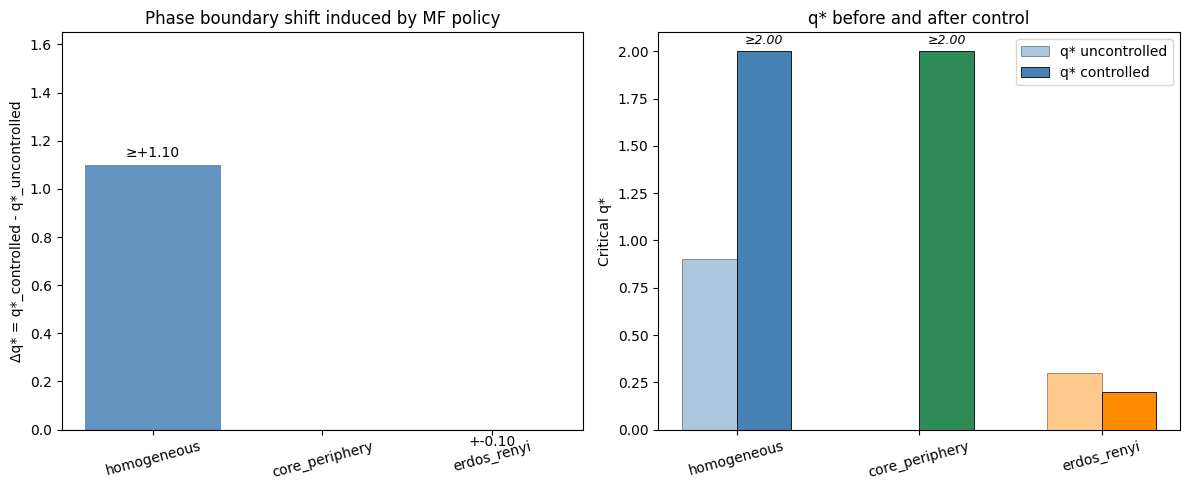


Phase boundary summary:
Topology                 q*_unc       q*_ctl          Δq*
----------------------------------------------------------
  homogeneous            0.9000      ≥2.0000     ≥+1.1000
  core_periphery            nan      ≥2.0000        ≥+nan
  erdos_renyi            0.3000       0.2000     +-0.1000


In [26]:
topo_list   = list(exp4.keys())
q_max_sweep = q4[-1]
topo_bar_colors = {'homogeneous': 'steelblue', 'core_periphery': 'seagreen', 'erdos_renyi': 'darkorange'}

q_unc_list, q_ctl_list, delta_q_list, ctl_capped = [], [], [], []
for topo in topo_list:
    cq_u = exp4[topo].get('critical_q_uncontrolled')
    cq_c = exp4[topo].get('critical_q_controlled')
    q_unc_list.append(cq_u if cq_u is not None else float('nan'))
    capped = (cq_c is None)
    q_ctl_list.append(q_max_sweep if capped else cq_c)
    if capped and cq_u is not None:
        delta_q_list.append(q_max_sweep - cq_u)  # lower bound
    elif cq_c is not None and cq_u is not None:
        delta_q_list.append(cq_c - cq_u)
    else:
        delta_q_list.append(float('nan'))
    ctl_capped.append(capped)

bar_colors = [topo_bar_colors.get(t, 'grey') for t in topo_list]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars = axes[0].bar(topo_list, delta_q_list, color=bar_colors, alpha=0.85)
axes[0].axhline(0, color='k', lw=0.8)
for bar, dq, capped in zip(bars, delta_q_list, ctl_capped):
    if dq == dq:  # not NaN
        lbl = f'≥+{dq:.2f}' if capped else f'+{dq:.2f}'
        axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                     lbl, ha='center', va='bottom', fontsize=10)
axes[0].set_ylabel('Δq* = q*_controlled - q*_uncontrolled')
axes[0].set_title('Phase boundary shift induced by MF policy')
axes[0].tick_params(axis='x', rotation=15)
valid_dq = [v for v in delta_q_list if v == v]
if valid_dq:
    axes[0].set_ylim(0, max(valid_dq) * 1.5)

x = list(range(len(topo_list)))
w = 0.3
b1 = axes[1].bar([i - w / 2 for i in x], q_unc_list, width=w,
                 color=bar_colors, alpha=0.45, label='q* uncontrolled',
                 edgecolor='k', linewidth=0.6)
b2 = axes[1].bar([i + w / 2 for i in x], q_ctl_list, width=w,
                 color=bar_colors, alpha=1.0, label='q* controlled',
                 edgecolor='k', linewidth=0.6)
for capped, bar in zip(ctl_capped, b2):
    if capped:
        axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                     f'≥{q_max_sweep:.2f}', ha='center', va='bottom', fontsize=9, style='italic')
axes[1].set_xticks(x)
axes[1].set_xticklabels(topo_list, rotation=15)
axes[1].set_ylabel('Critical q*')
axes[1].set_title('q* before and after control')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\nPhase boundary summary:')
print(f"{'Topology':<22} {'q*_unc':>8} {'q*_ctl':>12} {'Δq*':>12}")
print('-' * 58)
for topo, cq_u, cq_c_plot, dq, capped in zip(topo_list, q_unc_list, q_ctl_list, delta_q_list, ctl_capped):
    cq_c_str = f'≥{q_max_sweep:.4f}' if capped else f'{cq_c_plot:.4f}'
    dq_str   = f'≥+{dq:.4f}'         if capped else f'+{dq:.4f}'
    print(f"  {topo:<20} {cq_u:>8.4f} {cq_c_str:>12} {dq_str:>12}")

## Policy robustness across initial distributions

The MF policy was trained exclusively on **`case_1`** ($\mu_0 \sim \mathcal{N}(0, 0.2^2)$). Here we apply the same frozen checkpoint to agents initialised under `case_2` and `case_3`, at the same calibrated interaction strength $q^*$, across all three topologies.

This tests **distributional robustness**: does the learned control generalise beyond the training distribution when the mean-field hypothesis is already broken by a finite, heterogeneous network?


In [27]:
from pathlib import Path
from mfnn_control import ABMConfig

checkpoint_path = (ROOT / args.checkpoint).resolve()
policy_robust   = rae.load_policy_from_checkpoint(checkpoint_path, args.device)

abm_cfg_robust = ABMConfig(
    horizon=args.horizon,
    steps=args.steps,
    sigma=args.sigma,
    interaction_q=float(out['calibration']['selected_q']),
    state_dim=args.state_dim,
    default_threshold=args.default_threshold,
)
topo_robust = rae.build_topologies(args.agents, args.core_hubs, args.er_p, args.device)

CASES_ROBUST = ['case_1', 'case_2', 'case_3']
robust_results = {}
for c in CASES_ROBUST:
    robust_results[c] = rae.experiment_2_controlled(
        abm_cfg_robust, topo_robust, c,
        args.mc_paths, args.state_dim, args.device, policy_robust,
    )
    rate_red = {n: f'{robust_results[c][n]["cascade_reduction"]:.3f}' for n in names}
    size_red = {n: f'{robust_results[c][n]["cascade_size_reduction"]:.3f}' for n in names}
    print(f'{c}  rate_reduction={rate_red}')
    print(f'       size_reduction={size_red}')


case_1  rate_reduction={'homogeneous': '0.004', 'core_periphery': '0.000', 'erdos_renyi': '0.000'}
       size_reduction={'homogeneous': '10.370', 'core_periphery': '8.510', 'erdos_renyi': '8.802'}
case_2  rate_reduction={'homogeneous': '0.800', 'core_periphery': '0.652', 'erdos_renyi': '0.706'}
       size_reduction={'homogeneous': '1.852', 'core_periphery': '1.568', 'erdos_renyi': '1.646'}
case_3  rate_reduction={'homogeneous': '0.014', 'core_periphery': '0.002', 'erdos_renyi': '0.010'}
       size_reduction={'homogeneous': '8.956', 'core_periphery': '6.924', 'erdos_renyi': '7.326'}


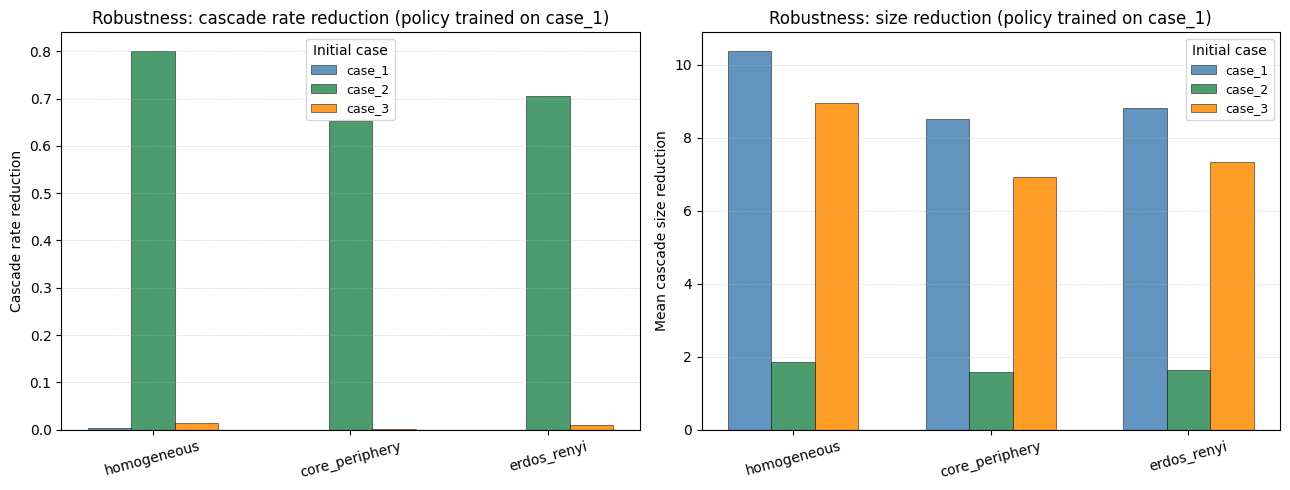


Rate reduction table:
Case                homogeneous        core_periphery           erdos_renyi
---------------------------------------------------------------------------
  case_1                 0.0040                0.0000                0.0000
  case_2                 0.8000                0.6520                0.7060
  case_3                 0.0140                0.0020                0.0100

Size reduction table:
Case                homogeneous        core_periphery           erdos_renyi
---------------------------------------------------------------------------
  case_1                10.3700                8.5100                8.8020
  case_2                 1.8520                1.5680                1.6460
  case_3                 8.9560                6.9240                7.3260


In [28]:
case_colors = {'case_1': 'steelblue', 'case_2': 'seagreen', 'case_3': 'darkorange'}
x = list(range(len(names)))
w = 0.22

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ci, c in enumerate(CASES_ROBUST):
    offset = (ci - 1) * w
    rate_reductions = [robust_results[c][n]['cascade_reduction']      for n in names]
    size_reductions = [robust_results[c][n]['cascade_size_reduction'] for n in names]
    axes[0].bar([xi + offset for xi in x], rate_reductions, width=w,
                label=c, color=case_colors[c], alpha=0.85, edgecolor='k', linewidth=0.4)
    axes[1].bar([xi + offset for xi in x], size_reductions, width=w,
                label=c, color=case_colors[c], alpha=0.85, edgecolor='k', linewidth=0.4)

for ax, ylabel in zip(axes, ['Cascade rate reduction', 'Mean cascade size reduction']):
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=15)
    ax.axhline(0, color='k', lw=0.8)
    ax.set_ylabel(ylabel)
    ax.legend(title='Initial case', fontsize=9)
    ax.grid(axis='y', ls='--', lw=0.5, alpha=0.5)

axes[0].set_title('Robustness: cascade rate reduction (policy trained on case_1)')
axes[1].set_title('Robustness: size reduction (policy trained on case_1)')
plt.tight_layout()
plt.show()

print('\nRate reduction table:')
print(f"{'Case':<10}", '  '.join(f'{n:>20}' for n in names))
print('-' * 75)
for c in CASES_ROBUST:
    vals = [f"{robust_results[c][n]['cascade_reduction']:>20.4f}" for n in names]
    print(f"  {c:<8}", '  '.join(vals))

print('\nSize reduction table:')
print(f"{'Case':<10}", '  '.join(f'{n:>20}' for n in names))
print('-' * 75)
for c in CASES_ROBUST:
    vals = [f"{robust_results[c][n]['cascade_size_reduction']:>20.4f}" for n in names]
    print(f"  {c:<8}", '  '.join(vals))